In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from numba import jit

from  InitialDistribution import Moleculas
from  McPackage import MC

In [2]:
Na   = 6.022e23              # 1/mol --> Avogadro number
T    = 600.0 + 273.15         # K         
Rcte = 1.987/1000          # kcal/mol K
RT   = Rcte*T
MW   = 104.15
V    = 1.0e-16 # 1.0e-16


In [3]:
t = 0.0
if T ==  (500.0 + 273.15):
    tend = 30  # seconds
    step = 1
elif T ==  (600.0 + 273.15):
    tend = 1.0  # seconds   
    step = 0.001
else: # T ==  (700.0 + 273.15):
    tend = 0.1  # seconds 
    step = 0.0001  
time_interval = np.arange(t, tend+step, step)


In [4]:
p_polymer = 1000/(0.9219+5.576e-4*(T-273.15) + 1.0648E-7*(T-273.15)**2) # DENSITY POLYMER (FUNCION OF TEMPERATURE)

p = 0.998  # Extent of reaction 
DP = 6000
x = np.linspace(0,DP,num=DP)  # Degree of polymerization
wx = x*((1-p)**2)*p**(x-1)      # Weight fraction 
print("Soma wx", np.sum(wx))
Mn_Flory = MW/(1-p)          # g/mol
Mw_Flory = (1+p)*MW/(1-p)    # g/mol 
print("Mn Flory:", Mn_Flory)
print("Mw Flory:", Mw_Flory)


print (" ")
print("Volume: ", V, " L")
print(" ")

Soma wx 0.9997544256607285
Mn Flory: 52074.999999999956
Mw Flory: 104045.8499999999
 
Volume:  1e-16  L
 


In [5]:
D,Dplotar,P0,Styrene_t0,X,R,Mn0,Mw0,Vsample,xPlotar,wx_PS = Moleculas(wx, Na, MW, p_polymer, V) # X, R, D     


Area PS original: 0.9980569550882273


In [6]:

#print("Initializing kMC")
print('\033[1m' + 'Initializing kMC' + '\033[0m')

print("tend", tend)

startime = time.time()
X,P,D2,D1_Unsat,D2_Unsat,Styrene,Dimer,Trimer,DeadPolymer,Rs,Rp,Rm,Mn_MC,Mw_MC,tfim,erro,SumBonds = MC(V, Na, RT, T, 0.0,tend,time_interval,X,R,D)
endtime = time.time() - startime
print(" ")
print("tCPU:", endtime/60, " min")

Initializing kMC
tend 1.0
kdm: 0.02962314183995223
kf0 0.017890252008904425
V: 1e-16
Na: 6.022e+23
R initial: R[23] =  7972908.722419248
kdmMC 4.90118240865397e-17
SumBonds[0] 445656591.0
time: 0.001 0.14 .X[12] Sty 0 X[26] 430220 0.0 . sumCCbonds: 445049531.0
time: 0.002 0.26 .X[12] Sty 0 X[26] 866919 0.0 . sumCCbonds: 444483233.0
time: 0.003 0.39 .X[12] Sty 0 X[26] 1311557 0.0 . sumCCbonds: 443907101.0
time: 0.004 0.52 .X[12] Sty 0 X[26] 1751185 0.0 . sumCCbonds: 443332353.0
time: 0.005 0.65 .X[12] Sty 0 X[26] 2194627 0.0 . sumCCbonds: 442742306.0
time: 0.006 0.79 .X[12] Sty 0 X[26] 2648368 0.0 . sumCCbonds: 442148692.0
time: 0.007 0.92 .X[12] Sty 0 X[26] 3094602 0.0 . sumCCbonds: 441553311.0
time: 0.008 1.05 .X[12] Sty 0 X[26] 3545533 0.0 . sumCCbonds: 440966322.0
time: 0.009 1.19 .X[12] Sty 0 X[26] 4003830 0.0 . sumCCbonds: 440362861.0
time: 0.01 1.32 .X[12] Sty 0 X[26] 4460648 0.0 . sumCCbonds: 439757964.0
time: 0.011 1.46 .X[12] Sty 0 X[26] 4920010 0.0 . sumCCbonds: 439141122.0
t

time: 0.109 17.44 .X[12] Sty 0 X[26] 55547333 0.0 . sumCCbonds: 367926645.0
time: 0.11 17.62 .X[12] Sty 0 X[26] 56094474 0.0 . sumCCbonds: 367131253.0
time: 0.111 17.8 .X[12] Sty 0 X[26] 56633549 0.0 . sumCCbonds: 366345665.0
time: 0.112 17.97 .X[12] Sty 0 X[26] 57173402 0.0 . sumCCbonds: 365556425.0
time: 0.113 18.15 .X[12] Sty 0 X[26] 57721249 0.0 . sumCCbonds: 364764735.0
time: 0.114 18.33 .X[12] Sty 0 X[26] 58268068 0.0 . sumCCbonds: 363969299.0
time: 0.115 18.51 .X[12] Sty 0 X[26] 58815864 0.0 . sumCCbonds: 363169080.0
time: 0.116 18.69 .X[12] Sty 0 X[26] 59362589 0.0 . sumCCbonds: 362373114.0
time: 0.117 18.87 .X[12] Sty 0 X[26] 59912088 0.0 . sumCCbonds: 361572943.0
time: 0.118 19.05 .X[12] Sty 0 X[26] 60462978 0.0 . sumCCbonds: 360768991.0
time: 0.119 19.22 .X[12] Sty 0 X[26] 61002164 0.0 . sumCCbonds: 359982794.0
time: 0.12 19.4 .X[12] Sty 0 X[26] 61545599 0.0 . sumCCbonds: 359189509.0
time: 0.121 19.58 .X[12] Sty 0 X[26] 62090449 0.0 . sumCCbonds: 358393134.0
time: 0.122 19.7

time: 0.22 37.22 .X[12] Sty 0 X[26] 115244553 0.0 . sumCCbonds: 279783603.0
time: 0.221 37.4 .X[12] Sty 0 X[26] 115768988 0.0 . sumCCbonds: 279000834.0
time: 0.222 37.57 .X[12] Sty 0 X[26] 116294424 0.0 . sumCCbonds: 278216750.0
time: 0.223 37.75 .X[12] Sty 0 X[26] 116814085 0.0 . sumCCbonds: 277439788.0
time: 0.224 37.92 .X[12] Sty 0 X[26] 117328463 0.0 . sumCCbonds: 276669889.0
time: 0.225 38.09 .X[12] Sty 0 X[26] 117844695 0.0 . sumCCbonds: 275899414.0
time: 0.226 38.27 .X[12] Sty 0 X[26] 118364270 0.0 . sumCCbonds: 275123552.0
time: 0.227 38.44 .X[12] Sty 0 X[26] 118881107 0.0 . sumCCbonds: 274348793.0
time: 0.228 38.61 .X[12] Sty 0 X[26] 119396551 0.0 . sumCCbonds: 273579266.0
time: 0.229 38.78 .X[12] Sty 0 X[26] 119909906 0.0 . sumCCbonds: 272810796.0
time: 0.23 38.96 .X[12] Sty 0 X[26] 120428035 0.0 . sumCCbonds: 272034120.0
time: 0.231 39.13 .X[12] Sty 0 X[26] 120941992 0.0 . sumCCbonds: 271267300.0
time: 0.232 39.31 .X[12] Sty 0 X[26] 121459377 0.0 . sumCCbonds: 270489025.0
ti

time: 0.327 55.0 .X[12] Sty 0 X[26] 167961294 0.0 . sumCCbonds: 200553972.0
time: 0.328 55.15 .X[12] Sty 0 X[26] 168420190 0.0 . sumCCbonds: 199861915.0
time: 0.329 55.31 .X[12] Sty 0 X[26] 168881326 0.0 . sumCCbonds: 199165387.0
time: 0.33 55.47 .X[12] Sty 0 X[26] 169339714 0.0 . sumCCbonds: 198472737.0
time: 0.331 55.62 .X[12] Sty 0 X[26] 169800215 0.0 . sumCCbonds: 197777097.0
time: 0.332 55.78 .X[12] Sty 0 X[26] 170256242 0.0 . sumCCbonds: 197088056.0
time: 0.333 55.93 .X[12] Sty 0 X[26] 170714971 0.0 . sumCCbonds: 196396419.0
time: 0.334 56.09 .X[12] Sty 0 X[26] 171174685 0.0 . sumCCbonds: 195702085.0
time: 0.335 56.24 .X[12] Sty 0 X[26] 171625986 0.0 . sumCCbonds: 195020024.0
time: 0.336 56.39 .X[12] Sty 0 X[26] 172083446 0.0 . sumCCbonds: 194330819.0
time: 0.337 56.55 .X[12] Sty 0 X[26] 172536694 0.0 . sumCCbonds: 193648124.0
time: 0.338 56.7 .X[12] Sty 0 X[26] 172993515 0.0 . sumCCbonds: 192957831.0
time: 0.339 56.86 .X[12] Sty 0 X[26] 173443088 0.0 . sumCCbonds: 192277553.0
ti

time: 0.435 70.48 .X[12] Sty 0 X[26] 213522071 0.0 . sumCCbonds: 131548987.0
time: 0.436 70.61 .X[12] Sty 0 X[26] 213908341 0.0 . sumCCbonds: 130960749.0
time: 0.437 70.74 .X[12] Sty 0 X[26] 214286808 0.0 . sumCCbonds: 130385296.0
time: 0.438 70.87 .X[12] Sty 0 X[26] 214663116 0.0 . sumCCbonds: 129814137.0
time: 0.439 71.0 .X[12] Sty 0 X[26] 215039052 0.0 . sumCCbonds: 129241768.0
time: 0.44 71.13 .X[12] Sty 0 X[26] 215414229 0.0 . sumCCbonds: 128673054.0
time: 0.441 71.25 .X[12] Sty 0 X[26] 215786950 0.0 . sumCCbonds: 128105469.0
time: 0.442 71.38 .X[12] Sty 0 X[26] 216164936 0.0 . sumCCbonds: 127532759.0
time: 0.443 71.51 .X[12] Sty 0 X[26] 216545720 0.0 . sumCCbonds: 126953003.0
time: 0.444 71.64 .X[12] Sty 0 X[26] 216917480 0.0 . sumCCbonds: 126387272.0
time: 0.445 71.77 .X[12] Sty 0 X[26] 217292219 0.0 . sumCCbonds: 125817870.0
time: 0.446 71.9 .X[12] Sty 0 X[26] 217667395 0.0 . sumCCbonds: 125248558.0
time: 0.447 72.02 .X[12] Sty 0 X[26] 218042001 0.0 . sumCCbonds: 124680824.0
ti

time: 0.546 83.25 .X[12] Sty 0 X[26] 250917399 0.0 . sumCCbonds: 74636895.0
time: 0.547 83.35 .X[12] Sty 0 X[26] 251210423 0.0 . sumCCbonds: 74190419.0
time: 0.548 83.45 .X[12] Sty 0 X[26] 251501106 0.0 . sumCCbonds: 73744630.0
time: 0.549 83.55 .X[12] Sty 0 X[26] 251789765 0.0 . sumCCbonds: 73304692.0
time: 0.55 83.65 .X[12] Sty 0 X[26] 252079217 0.0 . sumCCbonds: 72862834.0
time: 0.551 83.75 .X[12] Sty 0 X[26] 252369047 0.0 . sumCCbonds: 72420921.0
time: 0.552 83.85 .X[12] Sty 0 X[26] 252655102 0.0 . sumCCbonds: 71983192.0
time: 0.553 83.95 .X[12] Sty 0 X[26] 252940959 0.0 . sumCCbonds: 71547804.0
time: 0.554 84.04 .X[12] Sty 0 X[26] 253228886 0.0 . sumCCbonds: 71107712.0
time: 0.555 84.14 .X[12] Sty 0 X[26] 253516544 0.0 . sumCCbonds: 70669816.0
time: 0.556 84.24 .X[12] Sty 0 X[26] 253797636 0.0 . sumCCbonds: 70240830.0
time: 0.557 84.34 .X[12] Sty 0 X[26] 254079464 0.0 . sumCCbonds: 69811063.0
time: 0.558 84.43 .X[12] Sty 0 X[26] 254362895 0.0 . sumCCbonds: 69376747.0
time: 0.559 8

time: 0.657 92.5 .X[12] Sty 0 X[26] 277871688 0.0 . sumCCbonds: 33417872.0
time: 0.658 92.57 .X[12] Sty 0 X[26] 278065247 0.0 . sumCCbonds: 33120131.0
time: 0.659 92.64 .X[12] Sty 0 X[26] 278259920 0.0 . sumCCbonds: 32822164.0
time: 0.66 92.7 .X[12] Sty 0 X[26] 278453010 0.0 . sumCCbonds: 32525643.0
time: 0.661 92.77 .X[12] Sty 0 X[26] 278644026 0.0 . sumCCbonds: 32234235.0
time: 0.662 92.83 .X[12] Sty 0 X[26] 278833235 0.0 . sumCCbonds: 31942342.0
time: 0.663 92.9 .X[12] Sty 0 X[26] 279021288 0.0 . sumCCbonds: 31654587.0
time: 0.664 92.96 .X[12] Sty 0 X[26] 279205006 0.0 . sumCCbonds: 31373481.0
time: 0.665 93.03 .X[12] Sty 0 X[26] 279395613 0.0 . sumCCbonds: 31081699.0
time: 0.666 93.09 .X[12] Sty 0 X[26] 279582227 0.0 . sumCCbonds: 30794815.0
time: 0.667 93.15 .X[12] Sty 0 X[26] 279769066 0.0 . sumCCbonds: 30508994.0
time: 0.668 93.22 .X[12] Sty 0 X[26] 279951879 0.0 . sumCCbonds: 30228511.0
time: 0.669 93.28 .X[12] Sty 0 X[26] 280137528 0.0 . sumCCbonds: 29943456.0
time: 0.67 93.34

time: 0.77 98.11 .X[12] Sty 0 X[26] 294103306 0.0 . sumCCbonds: 8426899.0
time: 0.771 98.14 .X[12] Sty 0 X[26] 294195785 0.0 . sumCCbonds: 8284343.0
time: 0.772 98.17 .X[12] Sty 0 X[26] 294288845 0.0 . sumCCbonds: 8139966.0
time: 0.773 98.21 .X[12] Sty 0 X[26] 294380667 0.0 . sumCCbonds: 7997937.0
time: 0.774 98.24 .X[12] Sty 0 X[26] 294471972 0.0 . sumCCbonds: 7855605.0
time: 0.775 98.27 .X[12] Sty 0 X[26] 294562081 0.0 . sumCCbonds: 7716112.0
time: 0.776 98.3 .X[12] Sty 0 X[26] 294651653 0.0 . sumCCbonds: 7577794.0
time: 0.777 98.33 .X[12] Sty 0 X[26] 294738215 0.0 . sumCCbonds: 7444125.0
time: 0.778 98.36 .X[12] Sty 0 X[26] 294822717 0.0 . sumCCbonds: 7312232.0
time: 0.779 98.39 .X[12] Sty 0 X[26] 294907405 0.0 . sumCCbonds: 7180622.0
time: 0.78 98.42 .X[12] Sty 0 X[26] 294992445 0.0 . sumCCbonds: 7048686.0
time: 0.781 98.45 .X[12] Sty 0 X[26] 295075670 0.0 . sumCCbonds: 6918403.0
time: 0.782 98.48 .X[12] Sty 0 X[26] 295156639 0.0 . sumCCbonds: 6792656.0
time: 0.783 98.5 .X[12] Sty 

time: 0.895 99.94 .X[12] Sty 0 X[26] 299325278 0.0 . sumCCbonds: 277142.0
time: 0.896 99.94 .X[12] Sty 0 X[26] 299331212 0.0 . sumCCbonds: 267657.0
time: 0.897 99.94 .X[12] Sty 0 X[26] 299336567 0.0 . sumCCbonds: 258881.0
time: 0.898 99.94 .X[12] Sty 0 X[26] 299342060 0.0 . sumCCbonds: 250315.0
time: 0.899 99.95 .X[12] Sty 0 X[26] 299347427 0.0 . sumCCbonds: 241779.0
time: 0.9 99.95 .X[12] Sty 0 X[26] 299352946 0.0 . sumCCbonds: 233076.0
time: 0.901 99.95 .X[12] Sty 0 X[26] 299357381 0.0 . sumCCbonds: 225979.0
time: 0.902 99.95 .X[12] Sty 0 X[26] 299361922 0.0 . sumCCbonds: 218548.0
time: 0.903 99.95 .X[12] Sty 0 X[26] 299366288 0.0 . sumCCbonds: 211443.0
time: 0.904 99.95 .X[12] Sty 0 X[26] 299370513 0.0 . sumCCbonds: 204490.0
time: 0.905 99.96 .X[12] Sty 0 X[26] 299375055 0.0 . sumCCbonds: 197300.0
time: 0.906 99.96 .X[12] Sty 0 X[26] 299379396 0.0 . sumCCbonds: 190530.0
time: 0.907 99.96 .X[12] Sty 0 X[26] 299383205 0.0 . sumCCbonds: 184465.0
time: 0.908 99.96 .X[12] Sty 0 X[26] 299

In [7]:
print("CONVERSION-WITHOUT-CONSIDERED-POLYMER (%)")
print(" ")
print("Polymer:", np.round((SumBonds[0]-SumBonds[-1])*100/SumBonds[0],2))           # "Polymer:", np.round((X[0]+X[1]+X[2])*100/np.sum(X[3:]),2))
print(" ")
print("Mol %")
print(" ")
products = np.sum(X[12:17]) + np.sum(X[18:20]) + X[21] + np.sum(X[24:])
print("Monomer:", np.round(X[12]*100/products,2), X[26]*100/products)
print("alpha-Methylstyrene:", np.round(X[13]*100/products,2), X[27]*100/products)
print("DPP:", np.round(X[15]*100/products,2), X[2]*100/products)
print("Dimer:", np.round(X[14]*100/products,2), X[29]*100/products)
print("Trimer:", np.round(X[16]*100/products,2), X[30]*100/products)
print("Toluene:", np.round(X[19]*100/products, 2), X[24]*100/products)
print("Ethylbenzene:", X[18]*100/products, X[25]*100/products)
print(" ")

CONVERSION-WITHOUT-CONSIDERED-POLYMER (%)
 
Polymer: 100.0
 
Mol %
 
Monomer: 0.0 80.59964706174428
alpha-Methylstyrene: 0.0 1.078115560804006
DPP: 0.0 7.804498391768731e-06
Dimer: 0.0 3.2878949606017485
Trimer: 0.0 6.589927635479869
Toluene: 0.0 4.8920520132140926
Ethylbenzene: 0.0 0.08870781256528278
 


In [8]:
axis_x_1 = [7, 8, 9, 15, 16, 24]
labels = ['Toluene', 'Styrene', 'aMS', 'DPP', 'Dimer', 'Trimer']

print("ethylbenzene:", (X[18] + X[17])*100/np.sum(X[3:]))           # Ethylbenzene = C8H10
print("ethylbenzene:", (X[25])*100/np.sum(X[24:]))                  # Ethylbenzene = C8H10

ethylbenzene: 2.691122345033893e-07
ethylbenzene: 0.08870781256528278


In [9]:
C_Distribution     = np.zeros(6)
C_Distribution[0]  += X[24]           # X[19] + X[24] # X[19] + X[10]   # Toluene = C7H8
C_Distribution[1]  += X[26]           # X[12] + D2[1]   # Monomer = Styrene = C8H8  
C_Distribution[2]  += X[27]           # X[27]  + X[13] # X[9]  + X[13]    # Alpha-methylstyrene
C_Distribution[3]  += X[28]           # X[14] + D2[2]   # Dimer   = C16H16
C_Distribution[4]  += X[29]           # X[15] # + X[11]   # DPP     = C16H16
C_Distribution[5]  += X[30]           # X[16] + D2[3]   # Trimer  = C24H26 

print("C_Distribution", C_Distribution)
# C_Distribution[1]  += X[25] # X[18]        # + Ethylbenzene = C8H10

C_Distribution [1.81779150e+07 2.99492632e+08 4.00606800e+06 1.28702690e+07
 1.22171790e+07 2.44868910e+07]


In [10]:
mass_toluene      = X[24]*92.14/Na     # moleculas * mol/moleculas * g/mol = g 
mass_styrene      = X[26]*104.15/Na
mass_aMs          = X[27]*118.18/Na
mass_dimer        = X[28]*210.32/Na
mass_DPP          = X[29]*210.32/Na
mass_trimer       = X[30]*312.46/Na
mass_ethylbenzene = X[25]*106.17/Na
mass_products     = mass_toluene + mass_styrene + mass_aMs + mass_dimer + mass_DPP + mass_trimer + mass_ethylbenzene

print("mass_products", mass_products)
print("toluene:",mass_toluene*100/mass_products)
print("Monomer:",mass_styrene*100/mass_products)
print("aMS:",mass_aMs*100/mass_products)
print("Dimer:",mass_dimer*100/mass_products)
print("DPP:",mass_DPP*100/mass_products)
print("Trimer:",mass_trimer*100/mass_products)

mass_products 7.688985339410496e-14
toluene: 3.6172830407313405
Monomer: 67.36520454369794
aMS: 1.0224745770960606
Dimer: 5.845994645287313
DPP: 5.549345007048151
Trimer: 16.524118182942388


In [11]:
C_Distribution_Percentage = np.zeros(6)
C_Distribution_Percentage[0] = C_Distribution[0]*100/np.sum(X[24:]) # Toluene = C7H8 C_Distribution[0]*100/np.sum(X[3:]) 
C_Distribution_Percentage[1] = C_Distribution[1]*100/np.sum(X[24:]) # Monomer
C_Distribution_Percentage[2] = C_Distribution[2]*100/np.sum(X[24:]) # aMS
C_Distribution_Percentage[3] = C_Distribution[3]*100/np.sum(X[24:]) # Dimer
C_Distribution_Percentage[4] = C_Distribution[4]*100/np.sum(X[24:]) # DPP
C_Distribution_Percentage[5] = C_Distribution[5]*100/np.sum(X[24:]) # Trimer

C_Distribution_Percentage[0] *= 92.14
C_Distribution_Percentage[1] *= 104.15
C_Distribution_Percentage[2] *= 118.18
C_Distribution_Percentage[3] *= 210.32
C_Distribution_Percentage[4] *= 210.32
C_Distribution_Percentage[5] *= 312.46

C_Distribution_Percentage = C_Distribution_Percentage*100/np.sum(C_Distribution_Percentage)
C_Distribution_Percentage = np.round(C_Distribution_Percentage, 2)

In [12]:
C_Distribution_experimental = np.zeros(6)
C_Distribution_experimental_error = np.zeros(6)

if T == (500.0 + 273.15):
    C_Distribution_experimental[1] = 75.7 # Monomer
    C_Distribution_experimental[4] = 6.1 # Dimer
    C_Distribution_experimental[5] = 12.2  # Trimer
    C_Distribution_experimental[0] = 0.8 # Toluene = C7H8
    C_Distribution_experimental[2] = 0.2 # aMS
    C_Distribution_experimental[3] += 7.4 # DPP

    C_Distribution_experimental_error[1] = 6.1 # Monomer
    C_Distribution_experimental_error[4] = 1.2 # Dimer
    C_Distribution_experimental_error[5] = 4.0  # Trimer
    C_Distribution_experimental_error[0] = 0.8*0.05 # Toluene = C7H8
    C_Distribution_experimental_error[2] = 0.2*0.05 # aMS
    C_Distribution_experimental_error[3] += 6.1 # DPP 
    
elif T == (600.0 + 273.15):
    C_Distribution_experimental[1] = 76.4 # Monomer
    C_Distribution_experimental[4] = 4.2 # Dimer
    C_Distribution_experimental[5] = 8.5  # Trimer
    C_Distribution_experimental[0] = 0.75 # Toluene = C7H8
    C_Distribution_experimental[2] = 0.25 # aMS
    C_Distribution_experimental[3] += 0.55 # DPP

    C_Distribution_experimental_error[1] = 3.7 # Monomer
    C_Distribution_experimental_error[4] = 1.5 # Dimer
    C_Distribution_experimental_error[5] = 3.0  # Trimer
    C_Distribution_experimental_error[0] = 0.75*0.05 # Toluene = C7H8
    C_Distribution_experimental_error[2] = 0.25*0.05 # aMS
    C_Distribution_experimental_error[3] += 0.1 # DPP

else:
    C_Distribution_experimental[1] = 77.2 # Monomer
    C_Distribution_experimental[4] = 3.4  # Dimer
    C_Distribution_experimental[5] = 5.2  # Trimer
    C_Distribution_experimental[0] = 0.7  # Toluene = C7H8
    C_Distribution_experimental[2] = 0.4  # aMS
    C_Distribution_experimental[3] += 1.4 # DPP

    C_Distribution_experimental_error[1] = 1.1      # Monomer
    C_Distribution_experimental_error[4] = 3.4*0.05 # Dimer
    C_Distribution_experimental_error[5] = 5.2*0.5 # 0.3      # Trimer
    C_Distribution_experimental_error[0] = 0.7*0.05 # Toluene = C7H8
    C_Distribution_experimental_error[2] = 0.1      # aMS
    C_Distribution_experimental_error[3] = 0.3     # DPP



In [13]:
C_Distribution_experimental_error[0] /= C_Distribution_experimental[0]
C_Distribution_experimental_error[1] /= C_Distribution_experimental[1]
C_Distribution_experimental_error[2] /= C_Distribution_experimental[2]
C_Distribution_experimental_error[3] /= C_Distribution_experimental[3]
C_Distribution_experimental_error[4] /= C_Distribution_experimental[4]
C_Distribution_experimental_error[5] /= C_Distribution_experimental[5]  

In [14]:
C_Distribution_experimental[0] *= 92.14
C_Distribution_experimental[1] *= 104.15
C_Distribution_experimental[2] *= 118.18
C_Distribution_experimental[3] *= 210.32
C_Distribution_experimental[4] *= 210.32
C_Distribution_experimental[5] *= 312.46

C_Distribution_experimental = C_Distribution_experimental*100/np.sum(C_Distribution_experimental)
C_Distribution_experimental  = np.round(C_Distribution_experimental, 2)

In [15]:
C_Distribution_experimental_error[0] *= C_Distribution_experimental[0]
C_Distribution_experimental_error[1] *= C_Distribution_experimental[1]
C_Distribution_experimental_error[2] *= C_Distribution_experimental[2]
C_Distribution_experimental_error[3] *= C_Distribution_experimental[3]
C_Distribution_experimental_error[4] *= C_Distribution_experimental[4]
C_Distribution_experimental_error[5] *= C_Distribution_experimental[5]  

In [26]:
C_Distribution_Percentage = np.round(C_Distribution_Percentage, 1)
C_Distribution_experimental = np.round(C_Distribution_experimental, 1)


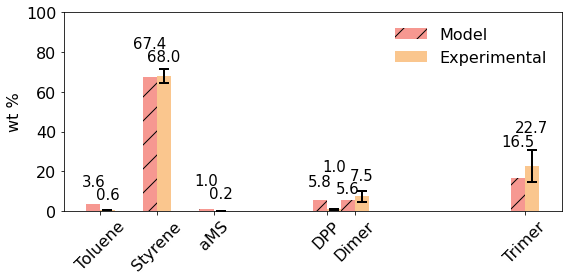

In [29]:
axis_x_1 = [7, 9, 11, 15, 16, 22]    # [7, 8, 9, 16, 24]
fig, ax = plt.subplots(figsize=(8,4))
width = 0.5
axis_x_2 = [p + width for p in axis_x_1]
axis_x_3 = [p + 0.5*width for p in axis_x_1]


plt.bar(axis_x_1, C_Distribution_Percentage, width, alpha=0.5, color='#EE3224', hatch='/', label='Model')
plt.bar(axis_x_2, C_Distribution_experimental, width, alpha=0.5, yerr=C_Distribution_experimental_error, error_kw=dict(ecolor='black', lw=2, capsize=5, capthick=2), color='#F78F1E', label='Experimental')
## plt.bar(axis_x_2[-2], 7.4, width, alpha=0.5, yerr=6.1, color='#FFC222', label='DPP') # experimental

# plt.bar(axis_x_2[-3], 6.1, width, alpha=1, yerr=1.2, error_kw=dict(ecolor='grey', lw=2, capsize=5, capthick=2), color='crimson', label='Dimer Exp.')   # experimental 
# plt.bar(axis_x_1[-3], (X[14] + D2[2])*100/np.sum(X[3:]), width, alpha=1, color='crimson', label='Dimer Model')   # experimental 


ax.set_ylabel('wt %', fontsize=16)
ax.set_xticks(axis_x_3)

ax.set_xticklabels(labels)
ax.annotate('{}'.format(C_Distribution_experimental[0]), xy=(axis_x_2[0], np.maximum(C_Distribution_experimental[0], C_Distribution_Percentage[0])), xytext=(0, 2), textcoords="offset points",  ha='center', va='bottom', fontsize=15)
ax.annotate('{}'.format(np.round(C_Distribution_Percentage[0],1)), xy=(axis_x_1[0], np.maximum(C_Distribution_experimental[0], C_Distribution_Percentage[0])), xytext=(0, 15), textcoords="offset points",  ha='center', va='bottom', fontsize=15)

ax.annotate('{}'.format(C_Distribution_experimental[2]), xy=(axis_x_2[2], np.maximum(C_Distribution_experimental[2], C_Distribution_Percentage[2])), xytext=(0, 8), textcoords="offset points",  ha='center', va='bottom', fontsize=15)
ax.annotate('{}'.format(np.round(C_Distribution_Percentage[2],1)), xy=(axis_x_1[2], np.maximum(C_Distribution_experimental[2], C_Distribution_Percentage[2])), xytext=(0, 21), textcoords="offset points",  ha='center', va='bottom', fontsize=15)

ax.annotate('{}'.format(C_Distribution_experimental[1]), xy=(axis_x_2[1], np.maximum(C_Distribution_experimental[1], C_Distribution_Percentage[1])), xytext=(0, 12), textcoords="offset points",  ha='center', va='bottom', fontsize=15)
ax.annotate('{}'.format(np.round(C_Distribution_Percentage[1],1)), xy=(axis_x_1[1], np.maximum(C_Distribution_experimental[1], C_Distribution_Percentage[1])), xytext=(0, 25), textcoords="offset points",  ha='center', va='bottom', fontsize=15)

ax.annotate('{}'.format(C_Distribution_experimental[3]), xy=(axis_x_2[3], np.maximum(C_Distribution_experimental[3], C_Distribution_Percentage[3])), xytext=(0, 25), textcoords="offset points",  ha='center', va='bottom', fontsize=15)
ax.annotate('{}'.format(np.round(C_Distribution_Percentage[3],1)), xy=(axis_x_1[3], np.maximum(C_Distribution_experimental[3], C_Distribution_Percentage[3])), xytext=(0, 10), textcoords="offset points",  ha='center', va='bottom', fontsize=15)
# ax.annotate('{}'.format("6.1 Dimer + 7.4 DPP"), xy=(axis_x_2[3], np.maximum(C_Distribution_experimental_500[3], C_Distribution_Percentage[3])), xytext=(0, 24), textcoords="offset points",  ha='center', va='bottom', fontsize=14)
# ax.annotate('{}'.format("3.8 Dimer + 3.1 DPP"), xy=(axis_x_1[3], np.maximum(C_Distribution_experimental_500[3], C_Distribution_Percentage[3])), xytext=(0, 2), textcoords="offset points",  ha='center', va='bottom', fontsize=14)

ax.annotate('{}'.format(C_Distribution_experimental[4]), xy=(axis_x_2[4], np.maximum(C_Distribution_experimental[4], C_Distribution_Percentage[4])), xytext=(0, 13), textcoords="offset points",  ha='center', va='bottom', fontsize=15)
ax.annotate('{}'.format(np.round(C_Distribution_Percentage[4],1)), xy=(axis_x_1[4], np.maximum(C_Distribution_experimental[4], C_Distribution_Percentage[4])), xytext=(0, 0), textcoords="offset points",  ha='center', va='bottom', fontsize=15)


ax.annotate('{}'.format(C_Distribution_experimental[5]), xy=(axis_x_2[5], np.maximum(C_Distribution_experimental[5], C_Distribution_Percentage[5])), xytext=(0, 31), textcoords="offset points",  ha='center', va='bottom', fontsize=15)
ax.annotate('{}'.format(np.round(C_Distribution_Percentage[5],1)), xy=(axis_x_1[5], np.maximum(C_Distribution_experimental[5], C_Distribution_Percentage[5])), xytext=(0, 17), textcoords="offset points",  ha='center', va='bottom', fontsize=15)


plt.xticks(fontsize=16, rotation=45)
plt.yticks(fontsize=16)

                
plt.ylim(0, 100)
plt.legend(frameon=False, fontsize=16)
plt.tight_layout()
plt.savefig("Fig8" + str(int(T-273.15)) + ".jpeg",format='jpeg',dpi = 1200,bbox_inches='tight')